# XGBoost - Student Health Risk

Dataset: Kaggle S6E7 (student health risk)
Target: health_condition (fit / at-risk / unhealthy)
Need train.csv in same folder.


1. Imports


In [1]:
# Uncomment if not installed
# %pip install xgboost -q

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

RANDOM_STATE = 42


2. Load data


In [3]:
students = pd.read_csv("train.csv")

NUMERIC_FEATURES = ["sleep_duration", "heart_rate", "bmi", "calorie_expenditure",
                     "step_count", "exercise_duration", "water_intake"]
CATEGORICAL_FEATURES = ["diet_type", "stress_level", "sleep_quality",
                         "physical_activity_level", "smoking_alcohol", "gender"]

for col in NUMERIC_FEATURES:
    students[col] = students[col].fillna(students[col].median())
for col in CATEGORICAL_FEATURES:
    students[col] = students[col].fillna("missing")

print("Shape:", students.shape)
print(students["health_condition"].value_counts(normalize=True).round(3))


Shape: (690088, 15)
health_condition
at-risk      0.859
unhealthy    0.084
fit          0.058
Name: proportion, dtype: float64


3. Split data

Using 150k rows sample so it trains faster.


In [4]:
students_sample, _ = train_test_split(
    students, train_size=150_000,
    stratify=students["health_condition"], random_state=RANDOM_STATE
)

X = students_sample[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = students_sample["health_condition"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

target_encoder = LabelEncoder()
y_train_enc = target_encoder.fit_transform(y_train)
y_test_enc = target_encoder.transform(y_test)

print("Train rows:", X_train.shape[0])
print("Test rows:", X_test.shape[0])
print("Class mapping:", dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_))))


Train rows: 112500
Test rows: 37500
Class mapping: {'at-risk': np.int64(0), 'fit': np.int64(1), 'unhealthy': np.int64(2)}


4. Preprocessing

One-hot encode categorical cols, keep numeric as is (trees don't need scaling).


In [5]:
preprocessor = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
    ("num", "passthrough", NUMERIC_FEATURES),
])


5. Train model


In [6]:
model_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", XGBClassifier(n_estimators=150, max_depth=5, learning_rate=0.1, subsample=0.85, colsample_bytree=0.85, eval_metric="mlogloss", random_state=RANDOM_STATE, n_jobs=-1))
])

model_pipeline.fit(X_train, y_train_enc)
print("Training complete.")


Training complete.


6. Evaluate


In [7]:
y_pred = model_pipeline.predict(X_test)
y_pred_labels = target_encoder.inverse_transform(y_pred)
y_proba = model_pipeline.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred_labels)
precision = precision_score(y_test, y_pred_labels, average="macro")
recall = recall_score(y_test, y_pred_labels, average="macro")
f1 = f1_score(y_test, y_pred_labels, average="macro")
roc_auc = roc_auc_score(y_test_enc, y_proba, multi_class="ovr", average="macro")

print(f"Accuracy:            {accuracy:.4f}")
print(f"Precision (macro):   {precision:.4f}")
print(f"Recall (macro):      {recall:.4f}")
print(f"F1 Score (macro):    {f1:.4f}")
print(f"ROC-AUC (OvR macro): {roc_auc:.4f}")


Accuracy:            0.9660
Precision (macro):   0.9440
Recall (macro):      0.8768
F1 Score (macro):    0.9076
ROC-AUC (OvR macro): 0.9822


7. Confusion matrix


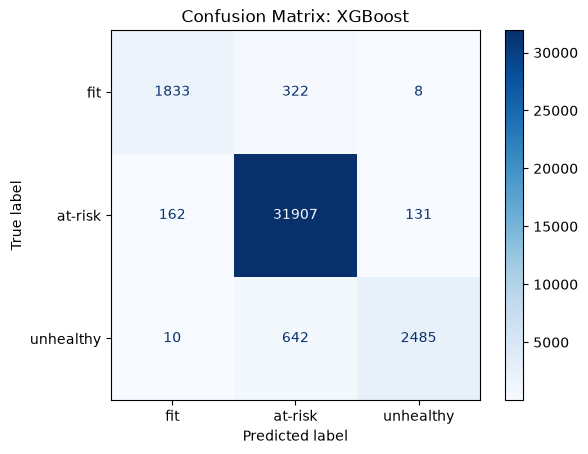

In [8]:
cm = confusion_matrix(y_test, y_pred_labels, labels=["fit", "at-risk", "unhealthy"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["fit", "at-risk", "unhealthy"])
disp.plot(values_format="d", cmap="Blues")
plt.title("Confusion Matrix: XGBoost")
plt.show()


8. Classification report


In [9]:
print(classification_report(y_test, y_pred_labels, target_names=["at-risk", "fit", "unhealthy"]))


              precision    recall  f1-score   support

     at-risk       0.97      0.99      0.98     32200
         fit       0.91      0.85      0.88      2163
   unhealthy       0.95      0.79      0.86      3137

    accuracy                           0.97     37500
   macro avg       0.94      0.88      0.91     37500
weighted avg       0.97      0.97      0.96     37500



9. Feature importance


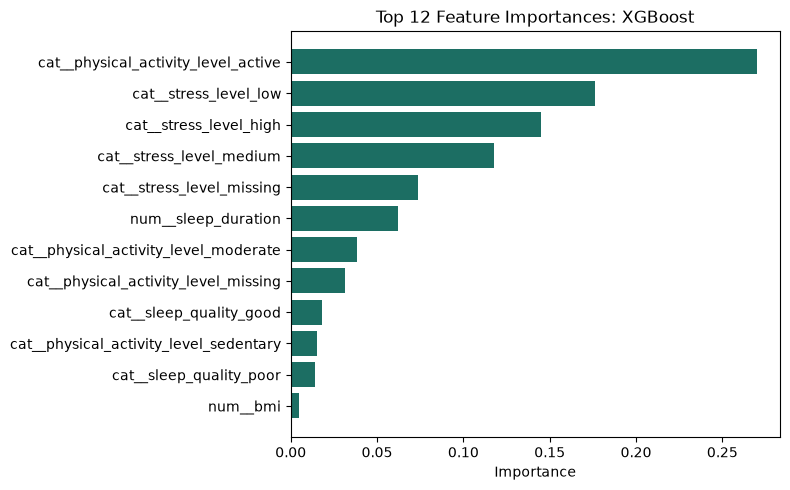

In [10]:
feature_names = model_pipeline.named_steps["preprocess"].get_feature_names_out()
fitted_model = model_pipeline.named_steps["model"]

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": fitted_model.feature_importances_
}).sort_values("importance", ascending=False).head(12)

plt.figure(figsize=(8, 5))
plt.barh(importance_df["feature"][::-1], importance_df["importance"][::-1], color="#1C6E63")
plt.title("Top 12 Feature Importances: XGBoost")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


10. Predict new students


In [11]:
new_students = pd.DataFrame({
    "sleep_duration": [7.5, 6.5, 5.0],
    "heart_rate": [70, 78, 95],
    "bmi": [21.5, 24.0, 31.0],
    "calorie_expenditure": [2400, 2200, 1800],
    "step_count": [9500, 6000, 3000],
    "exercise_duration": [45, 25, 5],
    "water_intake": [2.5, 2.0, 1.2],
    "diet_type": ["balanced", "non-veg", "non-veg"],
    "stress_level": ["low", "medium", "high"],
    "sleep_quality": ["good", "average", "poor"],
    "physical_activity_level": ["active", "moderate", "sedentary"],
    "smoking_alcohol": ["no", "occasional", "yes"],
    "gender": ["male", "female", "female"],
})

predictions = model_pipeline.predict(new_students)
predictions = target_encoder.inverse_transform(predictions)
probabilities = model_pipeline.predict_proba(new_students)

classes = target_encoder.classes_
for i, (pred, probs) in enumerate(zip(predictions, probabilities), start=1):
    prob_str = ", ".join(f"{c}={p:.2f}" for c, p in zip(classes, probs))
    print(f"Student {i}: Predicted = {pred}  ({prob_str})")


Student 1: Predicted = fit  (at-risk=0.01, fit=0.99, unhealthy=0.00)
Student 2: Predicted = at-risk  (at-risk=1.00, fit=0.00, unhealthy=0.00)
Student 3: Predicted = unhealthy  (at-risk=0.00, fit=0.00, unhealthy=1.00)


11. Save model


In [ ]:
joblib.dump({
    "pipeline": model_pipeline,
    "target_encoder": target_encoder,
    "model_name": "XGBoost",
    "feature_columns": NUMERIC_FEATURES + CATEGORICAL_FEATURES,
    "numeric_features": NUMERIC_FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "target_classes": list(classes),
    "test_accuracy": accuracy,
    "test_macro_f1": f1,
    "test_roc_auc_ovr": roc_auc,
}, "xgboost_model.pkl")

print("Saved xgboost_model.pkl")
print(f"Final results - Accuracy: {accuracy:.4f}, Macro F1: {f1:.4f}, ROC-AUC: {roc_auc:.4f}")


Saved xgboost_model.pkl
Final results — Accuracy: 0.9660, Macro F1: 0.9076, ROC-AUC: 0.9822


12. Summary

Trained, evaluated, saved model.
